# Unpaired T Test For Dataset 1

Load the libraries and the dataset

In [25]:
library(tidyverse)
library(ggplot2)
library(tidyr)
library(dplyr)
dataset1 <- read.csv("dataset1.csv")

Split the dataset into the two menus

In [2]:
toolpalette_data <- dataset1 %>% filter(menu == "toolpalette") %>% select(time)
flowmenu_data <- dataset1 %>% filter(menu == "flowmenu") %>% select(time)

Perform the Unpaired T Test

In [3]:
unpaired_t_test <- t.test(toolpalette_data$time, flowmenu_data$time)
print(unpaired_t_test)


	Welch Two Sample t-test

data:  toolpalette_data$time and flowmenu_data$time
t = 1.3951, df = 13.192, p-value = 0.186
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.1032322  0.4812322
sample estimates:
mean of x mean of y 
    2.969     2.780 



Conclusion from the ouptut of the unpaired T Test

The p-value of 0.186 is greater than the significance level of 0.05. Therefore, we can't reject the null hypothesis. The result shows that no statistically significant difference in means in user time taken to travel through either the toolpalette menu or the flowmenu.

Visualizations

In [4]:
stats <- dataset1 %>%
  group_by(menu) %>%
  summarise(
    mean_time = mean(time, na.rm = TRUE),
    sd_time = sd(time, na.rm = TRUE),
    median_time = median(time, na.rm = TRUE)
  )

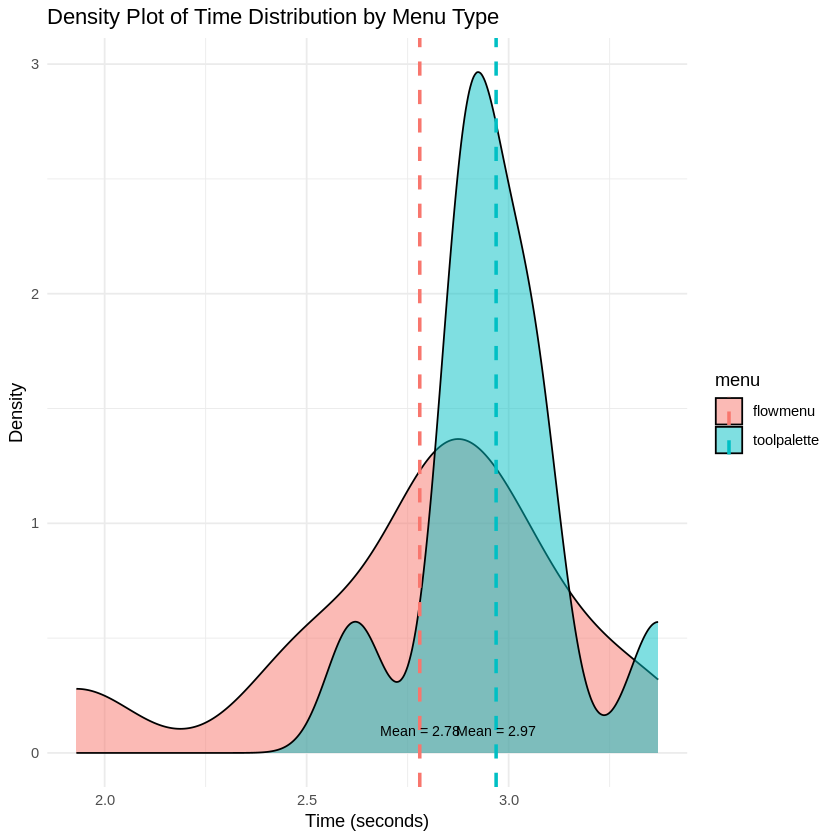

In [17]:
ggplot(dataset1, aes(x = time, fill = menu)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Time Distribution by Menu Type",
       x = "Time (seconds)",
       y = "Density") +
  theme_minimal() +
  geom_vline(data = stats, aes(xintercept = mean_time, color = menu),
             linetype = "dashed", size = 1) +
  geom_text(data = stats, aes(x = mean_time, y = 0.05, label = paste("Mean =", round(mean_time, 2))),
            color = "black", size = 3, vjust = -0.5)

From the density plot for both flowmenu and toolpalette in the dataset1 for unpaired t test. It can be seen that toolpalette has slightly higher mean time as compared to flowmenu. However, significant area of both the density curves overlap, hence it can be said that they are not statistically different.

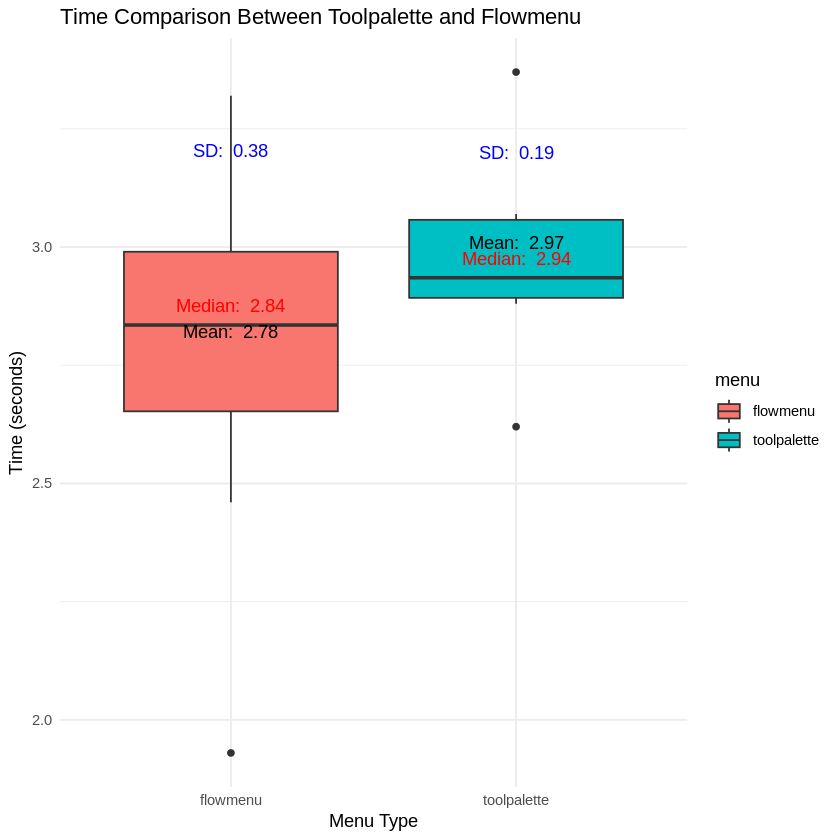

In [5]:
ggplot(dataset1, aes(x = menu, y = time, fill = menu)) +
  geom_boxplot() +
  labs(title = "Time Comparison Between Toolpalette and Flowmenu",
       x = "Menu Type", y = "Time (seconds)") +
  theme_minimal() +
  geom_text(data = stats, aes(x = menu, y = mean_time, label = paste("Mean: ", round(mean_time, 2))),
            vjust = -1, color = "black") +
  geom_text(data = stats, aes(x = menu, y = mean_time + sd_time, label = paste("SD: ", round(sd_time, 2))),
            vjust = -1, color = "blue") +
  geom_text(data = stats, aes(x = menu, y = median_time, label = paste("Median: ", round(median_time, 2))),
            vjust = -1, color = "red")


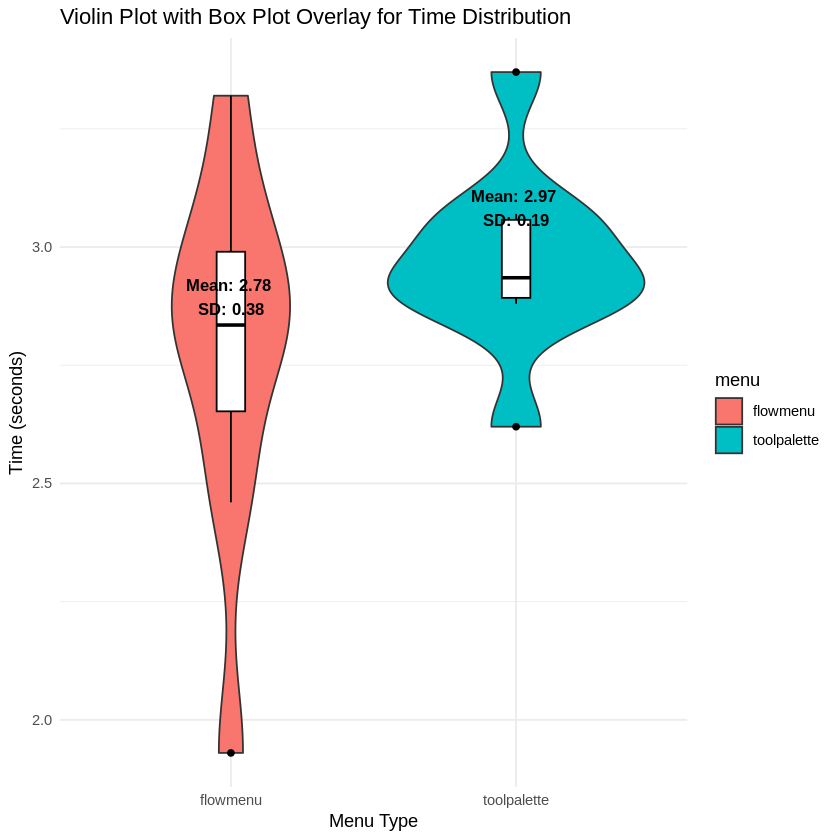

In [23]:
ggplot(dataset1, aes(x = menu, y = time, fill = menu)) +
  geom_violin() +
  geom_boxplot(width = 0.1, color = "black", fill = "white") +
  labs(title = "Violin Plot with Box Plot Overlay for Time Distribution",
       x = "Menu Type", y = "Time (seconds)") +
  theme_minimal() +
  geom_text(data = stats,
            aes(x = menu, y = mean_time,
                label = paste("Mean:", round(mean_time, 2), "\nSD:", round(sd_time, 2))),
            color = "black",
            vjust = -1,
            size = 3.5,
            fontface = "bold")

Both the box plot and violin plot depict that the toolpalette has a higher mean time but flowmenu has a higher standard deviation